<a href="https://colab.research.google.com/github/alrahaman/-geospatial_Python_tutorial/blob/main/ajari_mankendal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import ee
import geemap as gee

In [4]:
ee.Authenticate()
ee.Initialize(project = 'al-sakib-publishing')

In [9]:
cor = [[89.90653565663986,22.972149570628844],[91.00516846913986,22.972149570628844],[91.00516846913986,24.26559418838793],[89.90653565663986,24.26559418838793],
[89.90653565663986,22.972149570628844]]
roi = ee.Geometry.Polygon(cor)

In [10]:
roi

era = ee.ImageCollection("ECMWF/ERA5_LAND/MONTHLY_AGGR").select('temperature_2m').filterDate('1970','2024')

In [11]:
era

In [13]:
temp = era.map(lambda img: img.subtract(273.15).copyProperties(img,['system:time_start']))

In [14]:
temp

In [15]:
def ext_val(img):
  temp_val = img.reduceRegion(reducer = ee.Reducer.first(), geometry = roi, scale = 10000).values().get(0)
  date_val = img.date().format('YYYY-MM-dd')
  return ee.Feature(None, {'date': date_val, 'temp': temp_val})

In [16]:
temp_date_val = temp.map(ext_val)

In [17]:
temp_date_val


In [18]:
data_list = temp_date_val.toList(temp_date_val.size()).getInfo()
data_list

[{'type': 'Feature',
  'geometry': None,
  'id': '197001',
  'properties': {'date': '1970-01-01', 'temp': 17.812466824439298}},
 {'type': 'Feature',
  'geometry': None,
  'id': '197002',
  'properties': {'date': '1970-02-01', 'temp': 21.408752105349606}},
 {'type': 'Feature',
  'geometry': None,
  'id': '197003',
  'properties': {'date': '1970-03-01', 'temp': 26.094482491606072}},
 {'type': 'Feature',
  'geometry': None,
  'id': '197004',
  'properties': {'date': '1970-04-01', 'temp': 29.15534210205078}},
 {'type': 'Feature',
  'geometry': None,
  'id': '197005',
  'properties': {'date': '1970-05-01', 'temp': 30.175498232277505}},
 {'type': 'Feature',
  'geometry': None,
  'id': '197006',
  'properties': {'date': '1970-06-01', 'temp': 27.674697939554846}},
 {'type': 'Feature',
  'geometry': None,
  'id': '197007',
  'properties': {'date': '1970-07-01', 'temp': 27.838989142961395}},
 {'type': 'Feature',
  'geometry': None,
  'id': '197008',
  'properties': {'date': '1970-08-01', 'temp':

In [19]:
temp_list = [item['properties']['temp'] for item in data_list]
date_list = [item['properties']['date'] for item in data_list]

In [20]:
date_list

['1970-01-01',
 '1970-02-01',
 '1970-03-01',
 '1970-04-01',
 '1970-05-01',
 '1970-06-01',
 '1970-07-01',
 '1970-08-01',
 '1970-09-01',
 '1970-10-01',
 '1970-11-01',
 '1970-12-01',
 '1971-01-01',
 '1971-02-01',
 '1971-03-01',
 '1971-04-01',
 '1971-05-01',
 '1971-06-01',
 '1971-07-01',
 '1971-08-01',
 '1971-09-01',
 '1971-10-01',
 '1971-11-01',
 '1971-12-01',
 '1972-01-01',
 '1972-02-01',
 '1972-03-01',
 '1972-04-01',
 '1972-05-01',
 '1972-06-01',
 '1972-07-01',
 '1972-08-01',
 '1972-09-01',
 '1972-10-01',
 '1972-11-01',
 '1972-12-01',
 '1973-01-01',
 '1973-02-01',
 '1973-03-01',
 '1973-04-01',
 '1973-05-01',
 '1973-06-01',
 '1973-07-01',
 '1973-08-01',
 '1973-09-01',
 '1973-10-01',
 '1973-11-01',
 '1973-12-01',
 '1974-01-01',
 '1974-02-01',
 '1974-03-01',
 '1974-04-01',
 '1974-05-01',
 '1974-06-01',
 '1974-07-01',
 '1974-08-01',
 '1974-09-01',
 '1974-10-01',
 '1974-11-01',
 '1974-12-01',
 '1975-01-01',
 '1975-02-01',
 '1975-03-01',
 '1975-04-01',
 '1975-05-01',
 '1975-06-01',
 '1975-07-

In [21]:
import pandas as pd

In [22]:
df = pd.DataFrame({'date': date_list, 'temp': temp_list}).round(2)

df

,date,temp
0,1970-01-01,17.81
1,1970-02-01,21.41
2,1970-03-01,26.09
3,1970-04-01,29.16
4,1970-05-01,30.18
...,...,...
643,2023-08-01,28.64
644,2023-09-01,28.72
645,2023-10-01,26.61
646,2023-11-01,24.09


In [23]:
df.to_csv('temp_dataset.csv')

df['date'] = pd.to_datetime(df['date'])

df_annual = df.resample('YE', on = 'date').mean().round(2)

df_annual

,temp
date,
1970-12-31,25.11
1971-12-31,24.25
1972-12-31,25.57
1973-12-31,24.94
1974-12-31,24.74
1975-12-31,24.94
1976-12-31,25.11
1977-12-31,24.81
1978-12-31,24.74


Pettitt_Test(h=np.True_, cp=np.str_('2003-12-31'), p=np.float64(0.0078), U=np.float64(357.0), avg=mean(mu1=np.float64(24.942647058823532), mu2=np.float64(25.2435)))

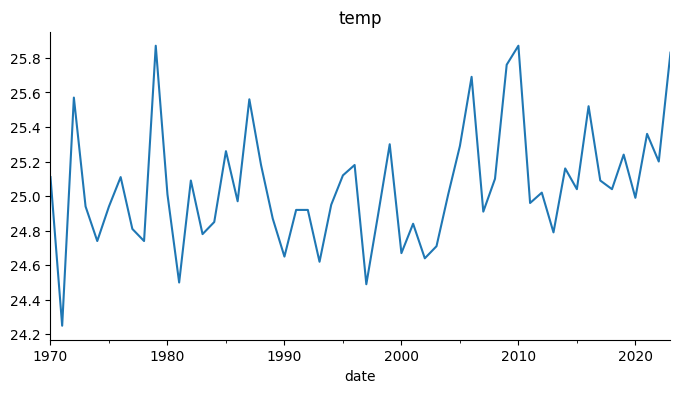

In [24]:
# @title temp

from matplotlib import pyplot as plt
df_annual['temp'].plot(kind='line', figsize=(8, 4), title='temp')
plt.gca().spines[['top', 'right']].set_visible(False)

!pip install pymannkendall

import pymannkendall as mk

mk_test = mk.original_test(df_annual)

mk_test

!pip install pyhomogeneity

import pyhomogeneity as ph

pet_test = ph.pettitt_test(df_annual)
pet_test